In [44]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import month_plot

In [2]:
df = pd.read_csv('AirPassengers.csv',parse_dates=['Month'], index_col='Month')

In [3]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


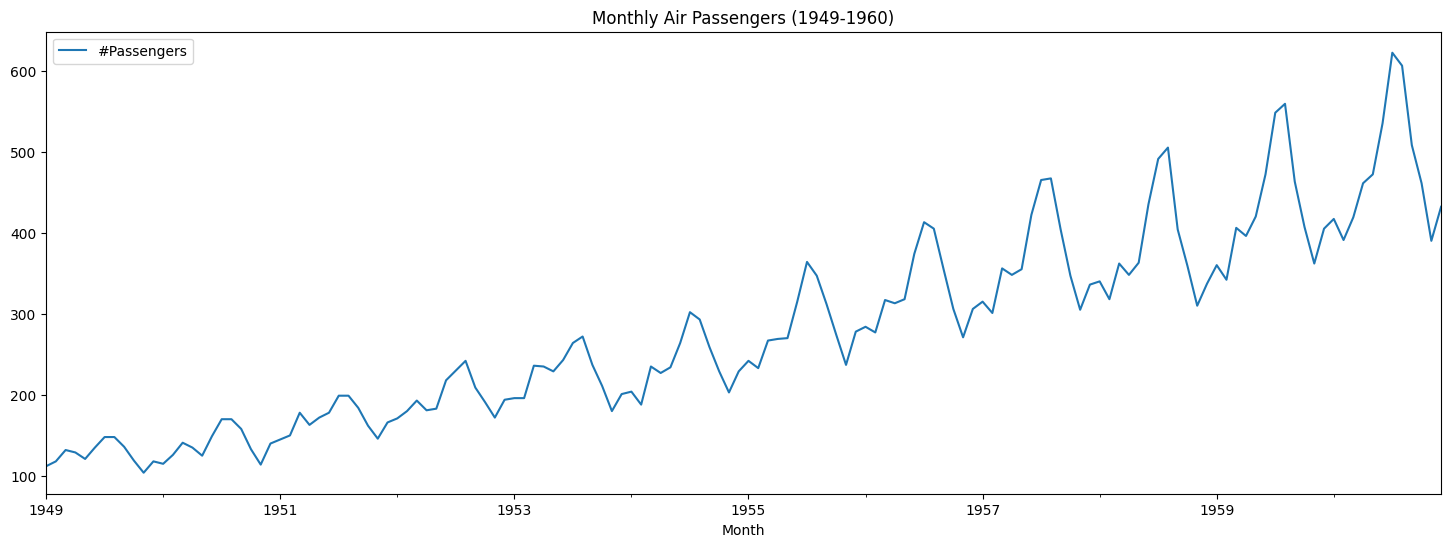

In [5]:
df.plot(figsize=(18, 6))
plt.title('Monthly Air Passengers (1949-1960)')
plt.show()

In [21]:
# From the dataset we can see that there is an slightly increasing trend observed .
# Also there might be some residuals in each cycle as the the peak of each cycle is seen to change .
# The seasonality observed here is multiplicative as the number of passengers keep on increasing by year from month to month

In [22]:
# We will use the import seasonal_decompose from statsmodels.tsa.seasonal to analyze the different components of the time-series-data.
decomposed_df = seasonal_decompose(df['#Passengers'],model='multiplicative') # <-- The seasonality was of type multiplicative as seen in the graph

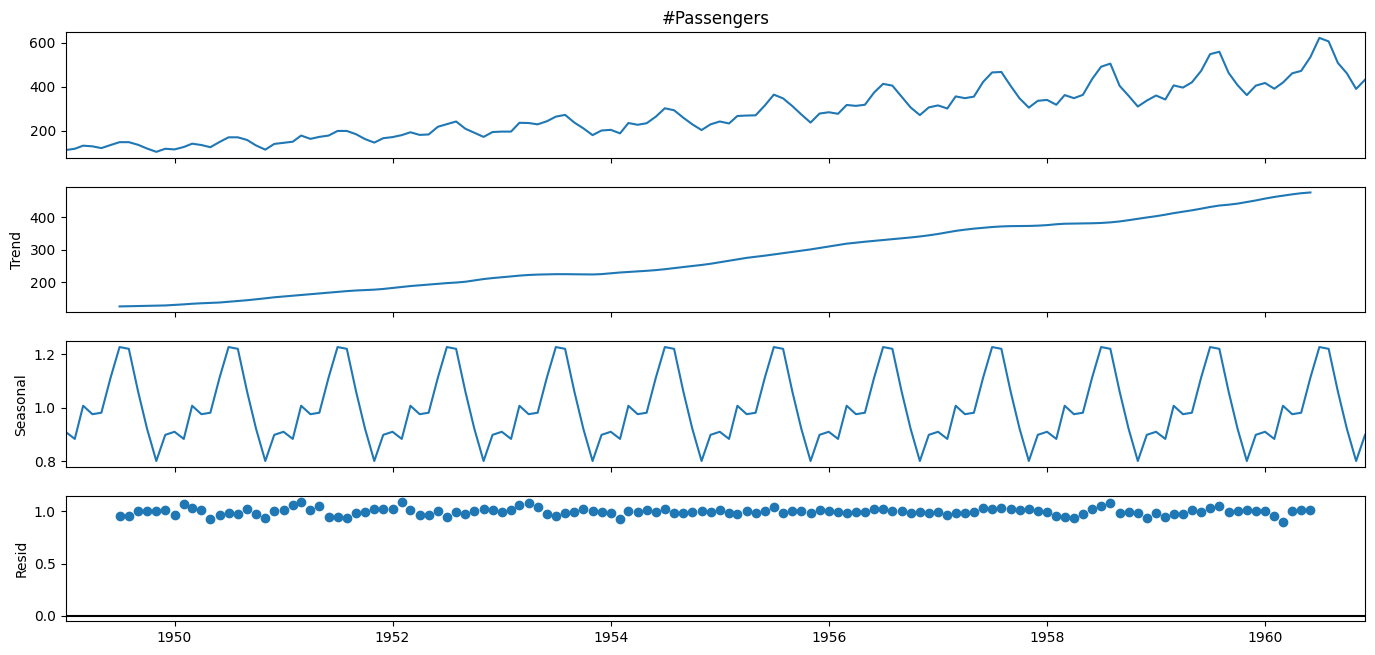

In [52]:
decomposed_df.plot()
plt.gcf().set_size_inches(15,7) # < -- Get the graph and set the size in inches accordingly
plt.show()

In [26]:
# We will seperate them and plot invidually for a better view.

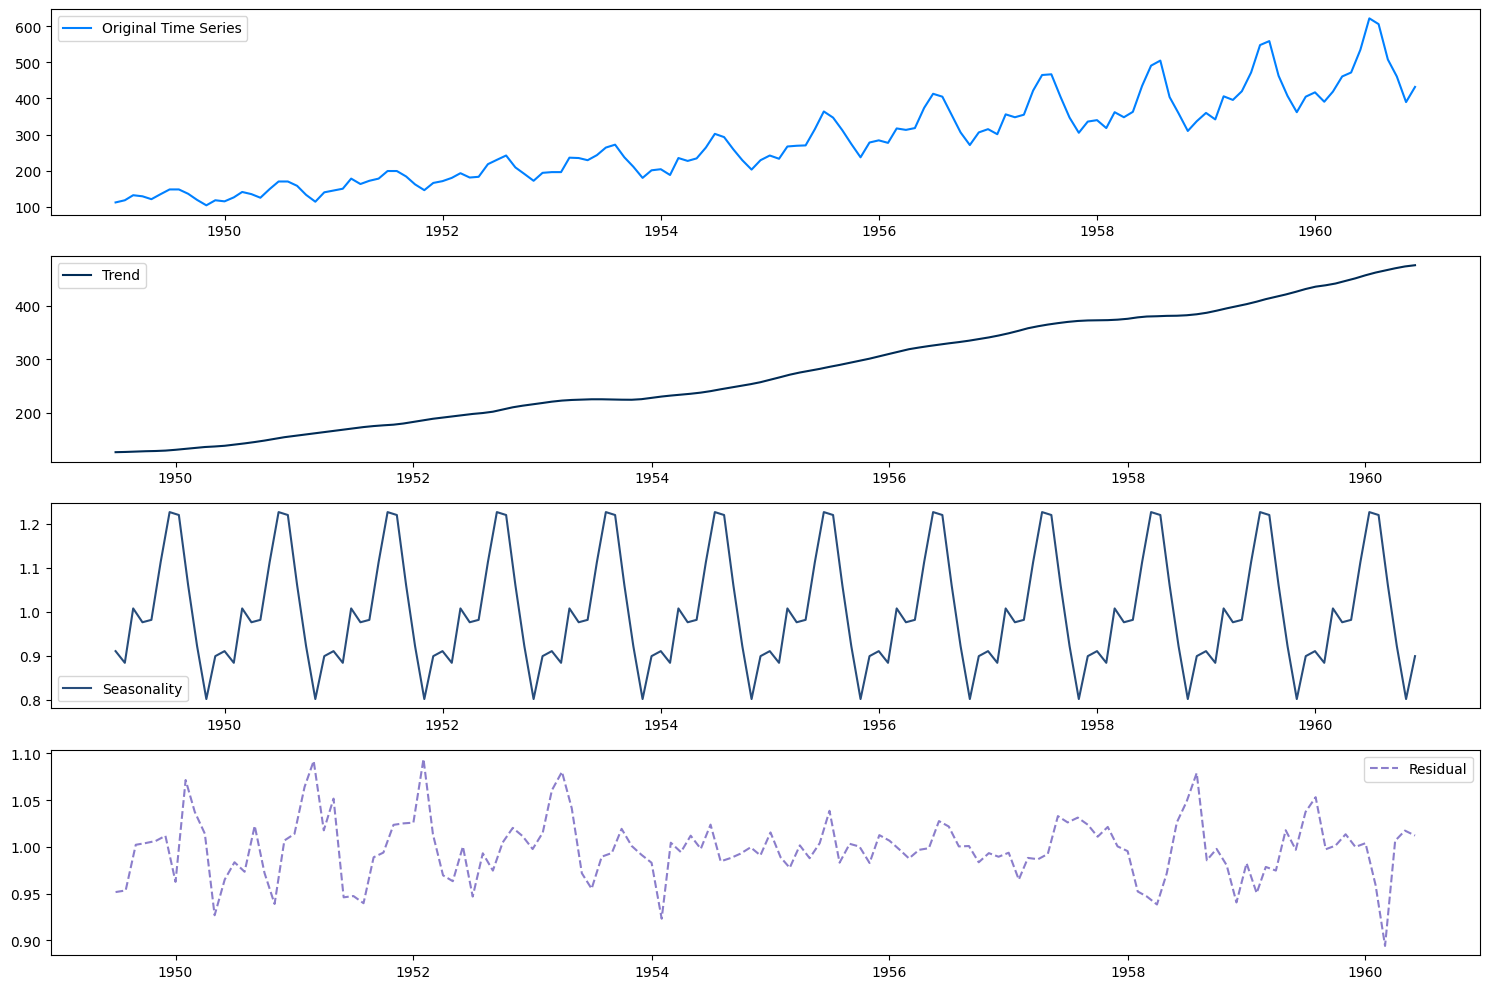

In [74]:
plt.figure(figsize=(15,10)) # <--  Adjust accordingly for better analysis

# Actual graph
plt.subplot(411)
plt.plot(df,'-',label='Original Time Series',color="#0080FF")
plt.legend(loc='best')

# Analysis of the trend
plt.subplot(412)
plt.plot(decomposed_df.trend,label='Trend',color="#002B55")
plt.legend(loc='best')

# Analysis of the Seasonality
plt.subplot(413)
plt.plot(decomposed_df.seasonal,label='Seasonality',color="#284D7B")
plt.legend(loc='best')

# Analysis of the Residual / Noise
plt.subplot(414)
plt.plot(decomposed_df.resid,'--',label='Residual',color="#8B7ECB")
plt.legend(loc='best')

plt.tight_layout()
plt.show()

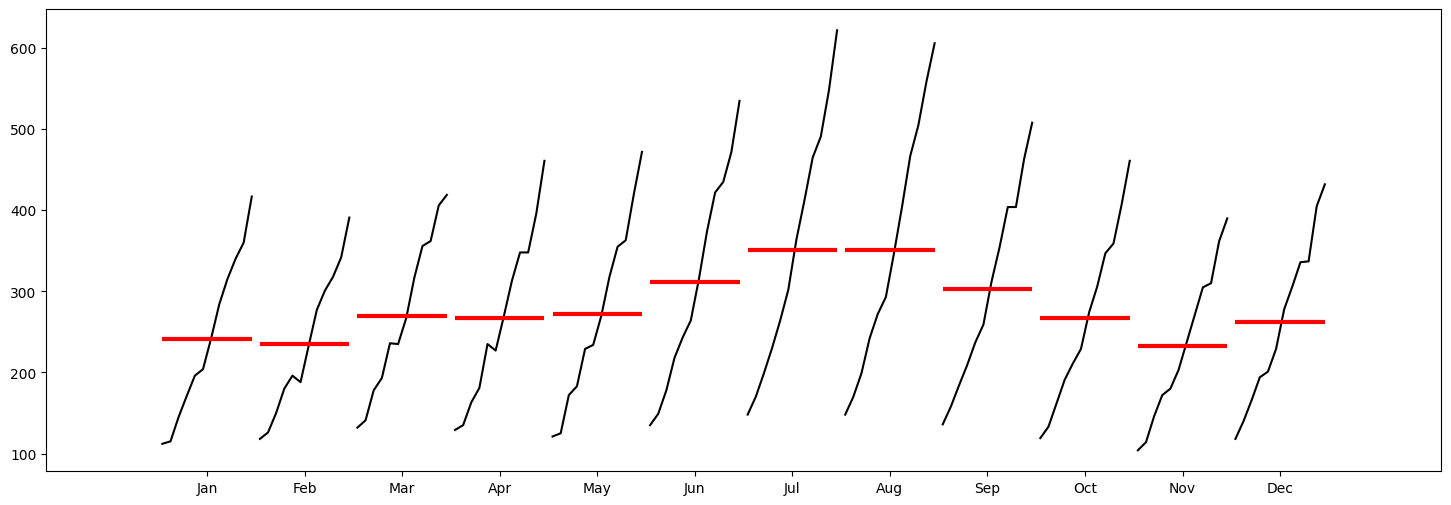

In [62]:
# This plot is to check the behaviour of the month across all the years ; to check for peak of years across all the years
month_plot(df['#Passengers'])
plt.gcf().set_size_inches(18,6)
plt.show()

In [76]:
# For time series forecasting using models like ARIMA we need a stable mean and variance
# We will check this using the rolling stats for each month mean and std

In [78]:
rolling_mean = df['#Passengers'].rolling(window=12).mean()
rolling_std = df['#Passengers'].rolling(window=12).std()

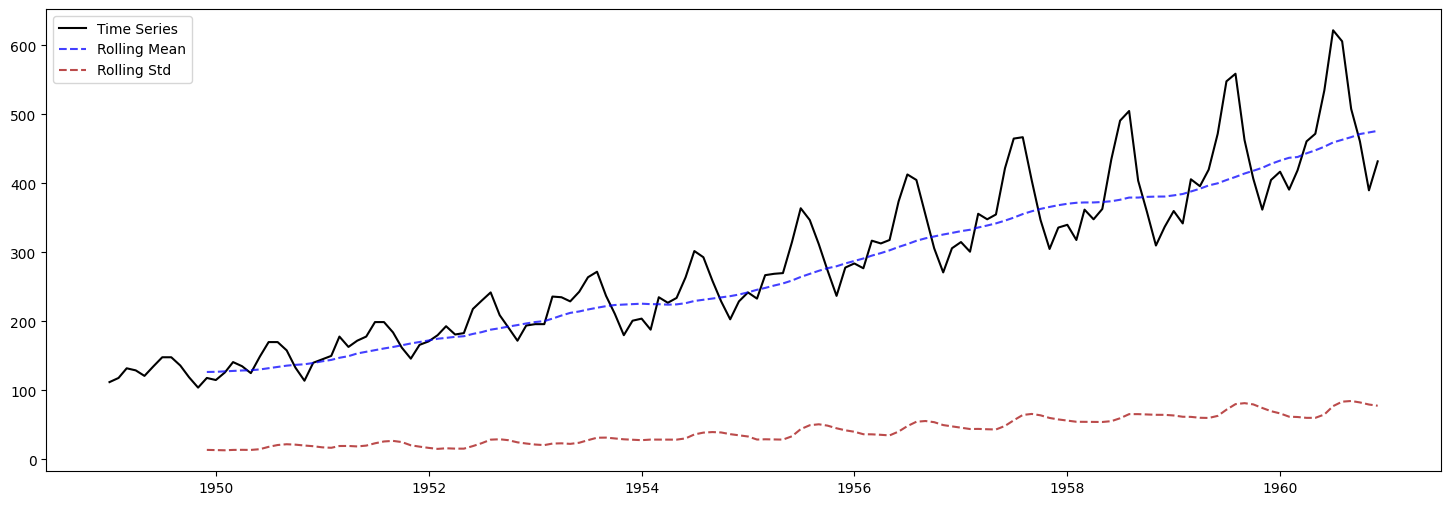

In [91]:
plt.figure(figsize=(18,6))

plt.plot(df['#Passengers'],label='Time Series',color='#000000')
plt.plot(rolling_mean,'--',label='Rolling Mean',color="#0400FF",alpha=0.75)
plt.plot(rolling_std,'--',label='Rolling Std',color="#A50F0F",alpha=0.75)

plt.legend()
plt.show()

In [92]:
# As we knew earlier that the trend was multiplicative now :
# we can clearly see that both rolling_mean and slightly rolling_std is increasing . 
# What this tells us ? --> We can't use models like ARIMA which assumes to have a stationary rolling_mean and std over time.
# We can either use log transformation at this point to convert it to stationary or use other models which can work on multiplicative seasonality.